# 1.单变量描述性统计

In [1]:
import numpy as np
import scipy as sp #scipy库是统计分析库

In [4]:
# 设置显示精度为3位小数
%precision 3 


'%.3f'

In [6]:
fish_data=np.array([2,3,3,4,4,4,4,5,5,6])
fish_data

array([2, 3, 3, 4, 4, 4, 4, 5, 5, 6])

In [10]:
np.sum(fish_data) # scipy库的sum函数已经过时，建议使用numpy库的sum函数

np.int64(40)

In [11]:
len(fish_data)

10

In [14]:
N=len(fish_data)
sum_value=np.sum(fish_data)
mu=sum_value/N
# mean()函数计算均值
# mu=np.mean(fish_data)
mu

4.000

In [24]:
sigma_2=np.sum((fish_data-mu)**2)/N
sigma_2

# np.var(fish_data)

1.200

In [26]:
sigma_2=np.sum((fish_data-mu)**2)/(N-1)
sigma_2
# var()函数计算方差
sigma_2=np.var(fish_data,ddof=1)
sigma_2

1.333

In [29]:
# 实现标准差
sigma=np.sqrt(sigma_2)
sigma


# std()函数计算标准差
sigma=np.std(fish_data,ddof=1)
sigma


1.155

In [30]:
# 数据标准化
data_normalized=(fish_data-mu)/sigma
data_normalized

array([-1.732, -0.866, -0.866,  0.   ,  0.   ,  0.   ,  0.   ,  0.866,
        0.866,  1.732])

In [34]:
np.mean(data_normalized)
np.std(data_normalized,ddof=1)

1.000

In [36]:
## 最值
max_value=np.max(fish_data)
max_value
min_value=np.min(fish_data)
max_value,min_value

(np.int64(6), np.int64(2))

In [39]:
## 中位数
median_value=np.median(fish_data)
median_value



4.000

均值易受极端值的影响，而中位数不易受极端值的影响。

因此中位数具有稳健性。

In [41]:
# 四分位数 
# 两种函数 stats.scoreatpercentile() 和 np.percentile()
from scipy import stats
q_20=stats.scoreatpercentile(fish_data,20)
q1=np.percentile(fish_data,25)
q1

q3=np.percentile(fish_data,75)
q1,q2,q3,q_20


(3.250, 4.000, 4.750, 3.000)

# 2.多变量描述性统计

In [43]:
import pandas as pd
fish=pd.read_csv('../pystat-code-2021-01-25/3-2-1-fish_multi.csv')
fish


,species,length
0,A,2
1,A,3
2,A,4
3,B,6
4,B,8
5,B,10


In [46]:
# 分组统计
group=fish.groupby('species')
group.mean(),group.median(),group.std(),group.var(),group.max(),group.min(),group.count()
group.describe()

length                                    
         count mean  std  min  25%  50%  75%   max
species                                           
A          3.0  3.0  1.0  2.0  2.5  3.0  3.5   4.0
B          3.0  8.0  2.0  6.0  7.0  8.0  9.0  10.0

- 实现列联表

In [49]:
shoes=pd.read_csv('../pystat-code-2021-01-25/3-2-2-shoes.csv')
# shoes

# pandas中的pivot_table()函数可以实现列联表
cross=pd.pivot_table(
    data=shoes,  # 指定数据
    values='sales',# 指定要计算的变量
    aggfunc='sum',# 指定统计函数（聚合函数）
    index='store', # 指定行
    columns='color'# 指定列
)
cross





color,blue,red
store,,
osaka,13,9
tokyo,10,15


- 实现协方差

In [64]:
cov_data=pd.read_csv('../pystat-code-2021-01-25/3-2-3-cov.csv')
# cov_data
x=cov_data.x
y=cov_data.y
N=len(cov_data)
mu_x=np.mean(x)
mu_y=np.mean(y)
cov_xy_sample=np.sum((x-mu_x)*(y-mu_y))/(N)
cov_xy=np.sum((x-mu_x)*(y-mu_y))/(N-1)
cov_xy
# 计算协方差矩阵的函数np.cov()
np.cov(x,y,ddof=0)


array([[ 3.282,  6.906],
       [ 6.906, 25.21 ]])

- 实现相关系数

In [65]:
sigma_2_x=np.var(x,ddof=1)
sigma_2_y=np.var(y,ddof=1)
rho=cov_xy/np.sqrt(sigma_2_x*sigma_2_y)
rho

# 相关系数不变
sima_2_x_sample=np.var(x,ddof=0)
sima_2_y_sample=np.var(y,ddof=0)
rho_sample=cov_xy_sample/np.sqrt(sima_2_x_sample*sima_2_y_sample)
rho_sample


0.759

In [66]:
# 使用np.corrcoef()计算相关系数矩阵
np.corrcoef(x,y)


array([[1.   , 0.759],
       [0.759, 1.   ]])

注：也有相关系数无效的情形

# 3.基于matplotlib、seaborn库的可视化分析

In [124]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Times New Roman']
matplotlib.rcParams['axes.unicode_minus'] = False

import seaborn as sns


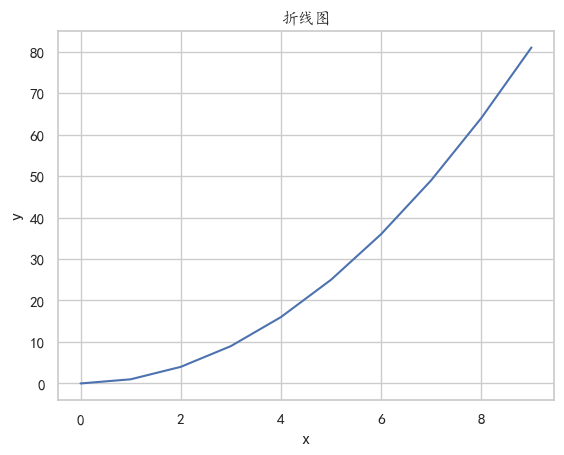

In [115]:
x=np.array([0,1,2,3,4,5,6,7,8,9])
y=np.array([0,1,4,9,16,25,36,49,64,81])
plt.plot(x,y)
plt.title('折线图')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig('折线图.png') # savefig()方法可以将图表保存为图片文件

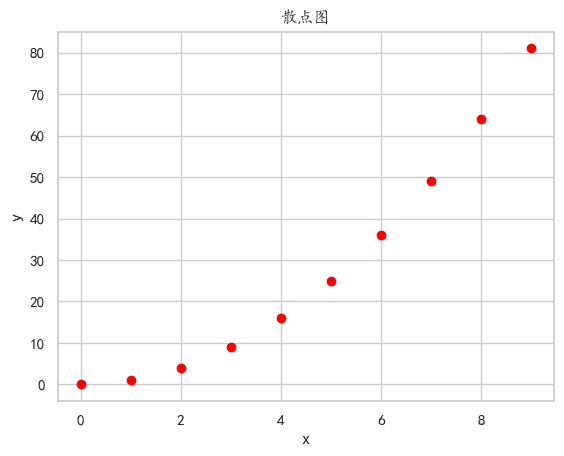

In [116]:
plt.scatter(x,y,color='red')
plt.title('散点图')
plt.xlabel('x')
plt.ylabel('y')
plt.savefig('散点图.png')


Text(0, 0.5, 'y')

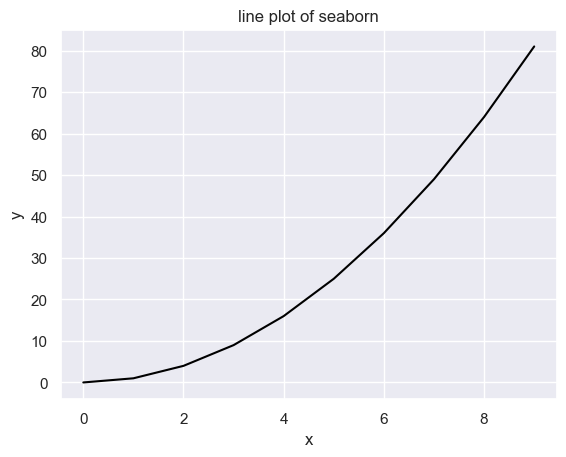

In [125]:
sns.set()
plt.plot(x,y,color='black')
plt.title('line plot of seaborn')
plt.xlabel('x')
plt.ylabel('y')

- 绘制直方图

<Axes: ylabel='Count'>

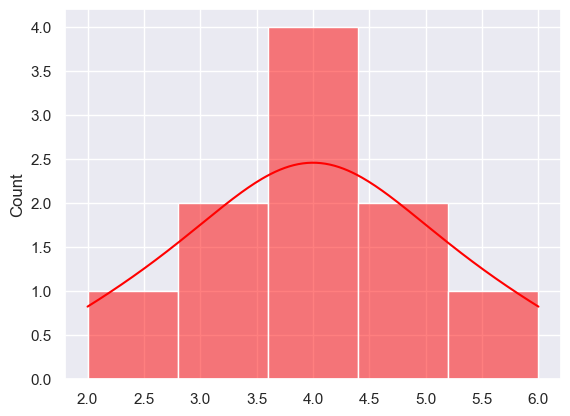

In [118]:
sns.histplot(fish_data,bins=5,color='red',kde=True) # kde表示绘制核密度估计曲线，bins表示直方图的柱子数量


<Axes: ylabel='Count'>

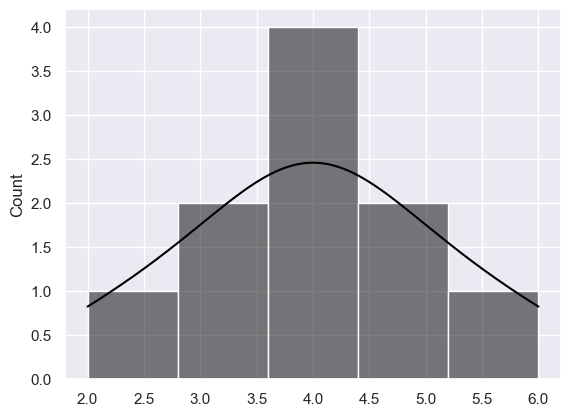

In [119]:
sns.histplot(fish_data,color='black',kde=True)

In [95]:
fish=pd.read_csv('../pystat-code-2021-01-25/3-3-2-fish_multi_2.csv')
# fish.head()
fish.groupby('species').describe()


length                                          
         count mean       std  min   25%  50%   75%  max
species                                                 
A         10.0  4.0  1.154701  2.0  3.25  4.0  4.75  6.0
B         10.0  7.0  1.154701  5.0  6.25  7.0  7.75  9.0

<Axes: xlabel='length', ylabel='Count'>

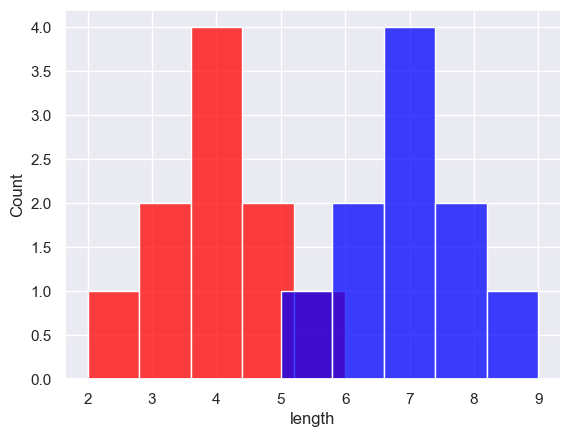

In [126]:
lenth_a=fish.query('species=="A"')['length']
lenth_b=fish.query('species=="B"')['length']

sns.histplot(lenth_a,bins=5,color='red',kde=False)
sns.histplot(lenth_b,bins=5,color='blue',kde=False)


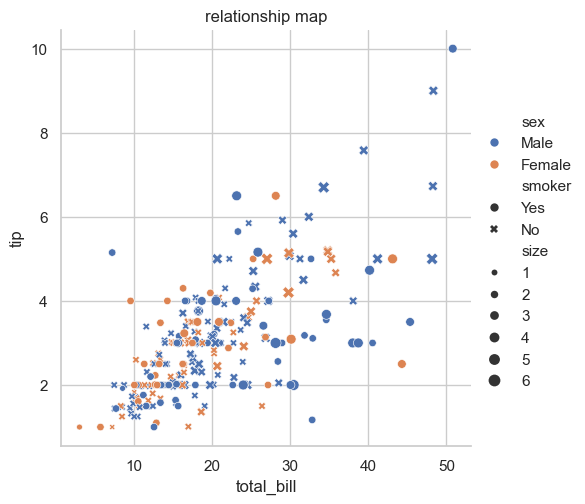

In [127]:
# 利用seaborn进行多变量可视化的代码
# sns. 函数名(
#     x = "x 轴对应的列名",
#     y = "y 轴对应的列名",
#     data = 数据帧,
#     其他参数
# )

# 加载示例数据
sns.set_style("whitegrid")
tips = sns.load_dataset("tips")  # 内置小费数据集


# 多变量散点图：x, y, hue(颜色), style(样式), size(大小)
sns.relplot(data=tips, x="total_bill", y="tip", 
            hue="sex", style="smoker", size="size")
plt.title('relationship map')
plt.show()

- 实现箱形图

<Axes: xlabel='species', ylabel='length'>

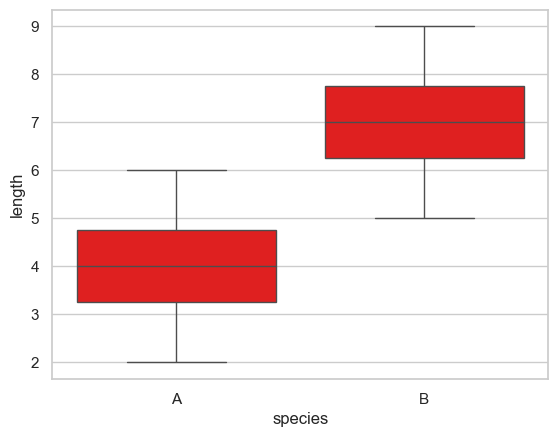

In [128]:
sns.boxplot(x='species',y='length',data=fish,color='red')

- 实现小提琴图

<Axes: xlabel='species', ylabel='length'>

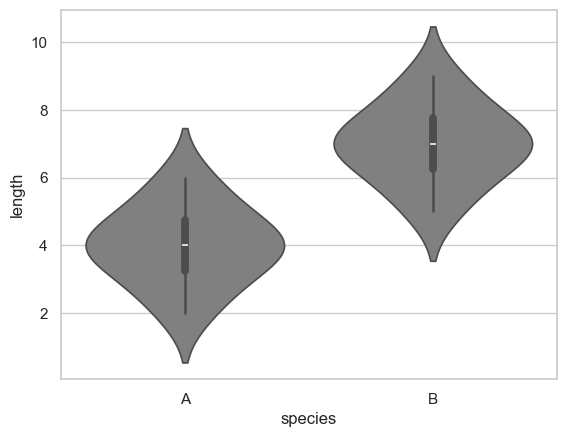

In [129]:
sns.violinplot(x='species',y='length',data=fish,color='gray')

- 实现条形图

<Axes: xlabel='species', ylabel='length'>

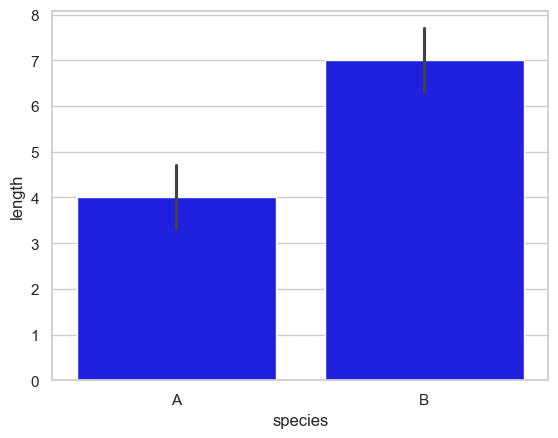

In [130]:
sns.barplot(x='species',y='length',data=fish,color='blue')

- 实现散点图

In [136]:
cov_data

,x,y
0,18.5,34
1,18.7,39
2,19.1,41
3,19.7,38
4,21.5,45
5,21.7,41
6,21.8,52
7,22.0,44
8,23.4,44
9,23.8,49


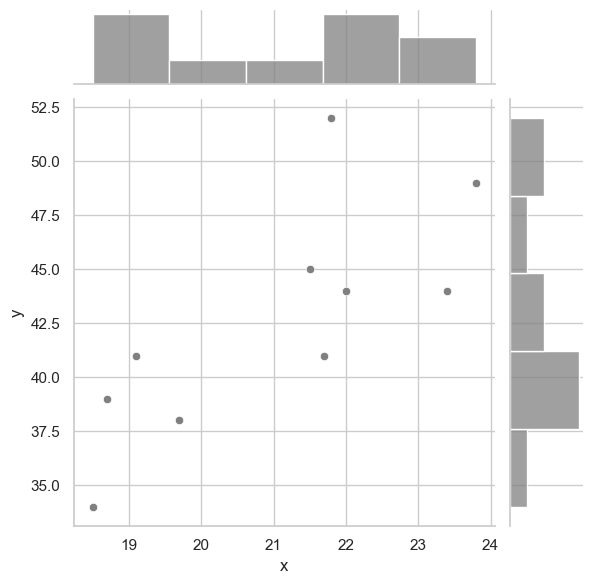

In [135]:

sns.jointplot(x='x',y='y',data=cov_data,color='gray')

- 散点图矩阵

In [137]:
iris=sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [139]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


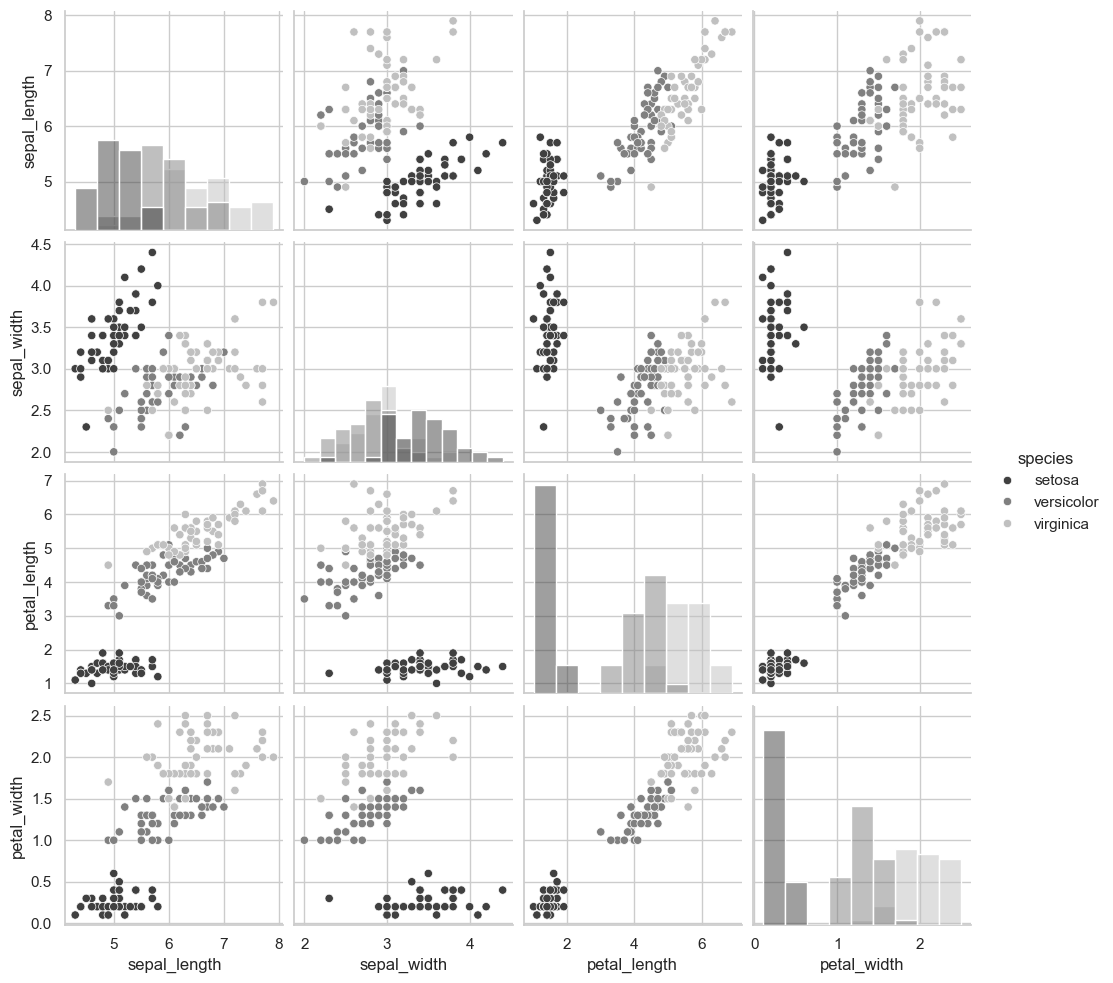

In [141]:
sns.pairplot(iris,hue='species',palette='gray',diag_kind='hist')

# 4.用python模拟抽样

In [150]:
fish5=np.array([2,3,4,5,6])
np.random.choice(fish5,size=3,replace=False)# replace=False表示不重复抽样  不放回抽样   

array([5, 2, 3])

In [152]:
np.random.seed(1)
np.mean(np.random.choice(fish5,size=3,replace=False))

4.333

In [154]:
# 总体是10万条鱼的体长数据
fish_100000=pd.read_csv('../pystat-code-2021-01-25/3-4-1-fish_length_100000.csv')['length']
print(fish_100000.head())


0    5.297442
1    3.505566
2    3.572546
3    3.135979
4    4.689275
Name: length, dtype: float64


In [165]:
sample=np.random.choice(fish_100000,size=10,replace=False)
sample
sample.mean(),sample.std(),sample.var()
np.mean(fish_100000),np.std(fish_100000),np.var(fish_100000)

(4.000, 0.800, 0.640)

<Axes: xlabel='length', ylabel='Count'>

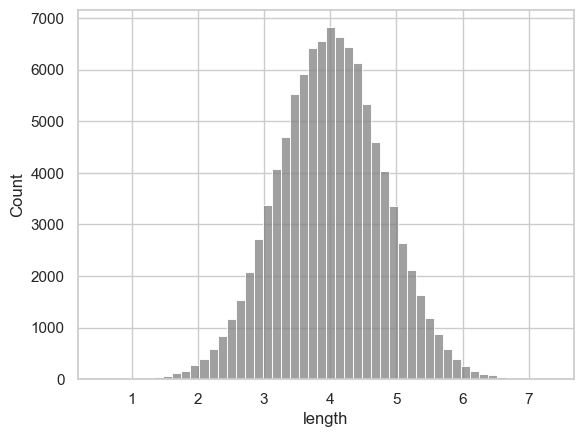

In [158]:
sns.histplot(fish_100000,bins=50,kde=False,color='gray')

In [159]:
x=np.arange(1,7,0.1)
x

array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2,
       2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5,
       3.6, 3.7, 3.8, 3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8,
       4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1,
       6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9])

In [160]:
stats.norm.pdf(x,loc=4,scale=0.8) # stats.norm.pdf()函数返回的是概率密度函数的值

array([4.407e-04, 6.988e-04, 1.091e-03, 1.676e-03, 2.536e-03, 3.778e-03,
       5.540e-03, 7.998e-03, 1.137e-02, 1.591e-02, 2.191e-02, 2.971e-02,
       3.967e-02, 5.215e-02, 6.749e-02, 8.598e-02, 1.078e-01, 1.332e-01,
       1.619e-01, 1.938e-01, 2.283e-01, 2.648e-01, 3.025e-01, 3.401e-01,
       3.764e-01, 4.102e-01, 4.401e-01, 4.648e-01, 4.833e-01, 4.948e-01,
       4.987e-01, 4.948e-01, 4.833e-01, 4.648e-01, 4.401e-01, 4.102e-01,
       3.764e-01, 3.401e-01, 3.025e-01, 2.648e-01, 2.283e-01, 1.938e-01,
       1.619e-01, 1.332e-01, 1.078e-01, 8.598e-02, 6.749e-02, 5.215e-02,
       3.967e-02, 2.971e-02, 2.191e-02, 1.591e-02, 1.137e-02, 7.998e-03,
       5.540e-03, 3.778e-03, 2.536e-03, 1.676e-03, 1.091e-03, 6.988e-04])

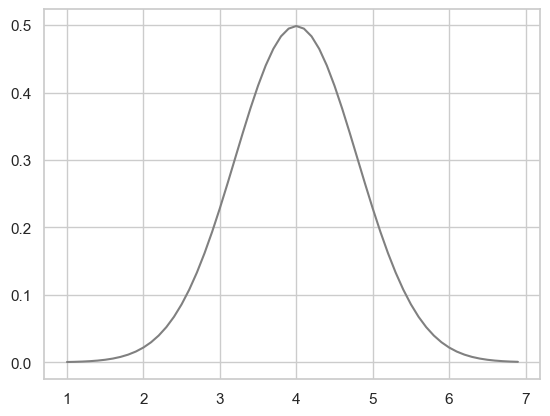

In [161]:
plt.plot(x,stats.norm.pdf(x,loc=4,scale=0.8),color='gray')

C:\Users\ZYF\AppData\Local\Temp\ipykernel_42260\2219628445.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(fish_100000,bins=50,norm_hist=True,kde=False,color='gray')


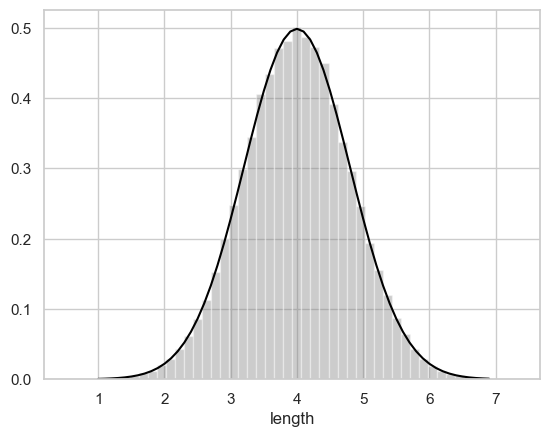

In [169]:
sns.distplot(fish_100000,bins=50,norm_hist=True,kde=False,color='gray')
plt.plot(x,stats.norm.pdf(x,loc=4,scale=0.8),color='black')

In [171]:
sampling_norm=stats.norm.rvs(loc=4,scale=0.8,size=10) # stats.norm.rvs()函数从正态分布中采样
sampling_norm
np.mean(sampling_norm)


3.983

# 5.样本统计量的性质

In [ ]:
# 研究均值为4，标准差为0.8的正态分布总体
population=stats.norm(4,0.8)

In [175]:
sample_mean_array=np.zeros(10000)
np.random.seed(123)
for i in range(10000):
    sample=population.rvs(size=10)
    sample_mean_array[i]=np.mean(sample)

sample_mean_array

array([3.784, 4.399, 3.924, ..., 3.826, 4.497, 4.225])

### 性质一：样本均值与总体均值接近

In [176]:
np.mean(sample_mean_array)

4.001

In [177]:
# 标准差相差较大
np.std(sample_mean_array)

0.251

C:\Users\ZYF\AppData\Local\Temp\ipykernel_42260\1296431265.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample_mean_array,color='black')


<Axes: ylabel='Density'>

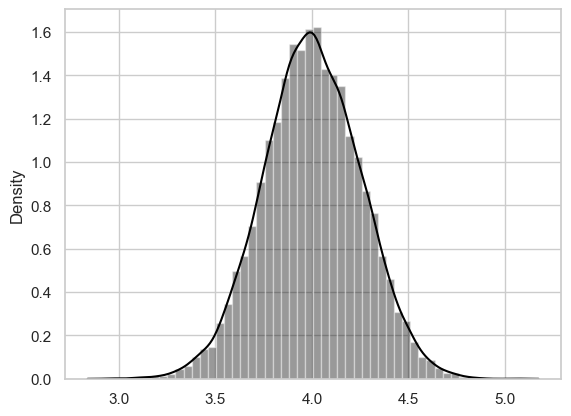

In [178]:
sns.distplot(sample_mean_array,color='black')

### 性质二：样本容量越大，样本均值越接近总体均值

Text(0, 0.5, 'Sample Mean')

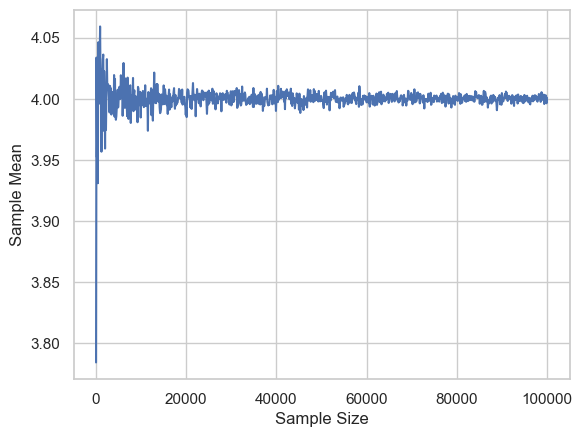

In [182]:
# 验证
size_array=np.arange(10,100100,100)
sample_mean_array_size=np.zeros(len(size_array))
np.random.seed(123)
for i in range(len(size_array)):
    sample=population.rvs(size=size_array[i])
    sample_mean_array_size[i]=np.mean(sample)

plt.plot(size_array,sample_mean_array_size)
plt.xlabel('Sample Size')
plt.ylabel('Sample Mean')


定义一个计算样本均值的函数

In [189]:
def calculate_sample_mean(size,n_trial):
    sample_mean_array=np.zeros(n_trial)
    for i in range(n_trial):
        sample_mean_array[i]=np.mean(population.rvs(size=size))
    return sample_mean_array

In [196]:
n=10000
for i in np.arange(10,110,10):
    size_i=calculate_sample_mean(i,n)
    print(f'size_{i}的均值与总体均值的差值为：{np.mean(size_i)-population.mean()}')
    

size_10的均值与总体均值的差值为：0.0043323006678415155
size_20的均值与总体均值的差值为：0.00032114011490147476
size_30的均值与总体均值的差值为：0.002069428139498619
size_40的均值与总体均值的差值为：0.002331246442426327
size_50的均值与总体均值的差值为：-0.002161412908796123
size_60的均值与总体均值的差值为：-0.0020527983090867785
size_70的均值与总体均值的差值为：-0.001374545402524241
size_80的均值与总体均值的差值为：0.0003871562040345111
size_90的均值与总体均值的差值为：0.0005972600295223174
size_100的均值与总体均值的差值为：0.0007722113881962755


<Axes: xlabel='size', ylabel='sample_mean'>

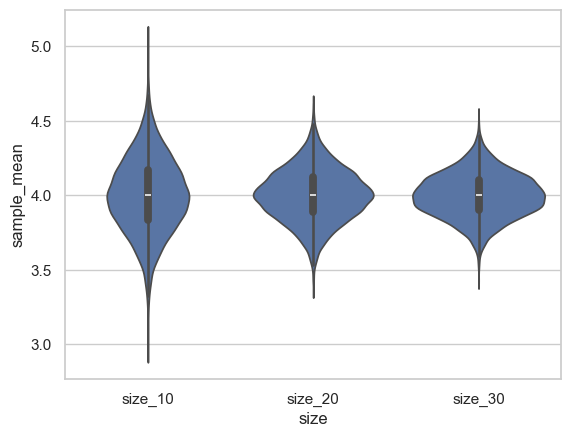

In [198]:
np.random.seed(123)
size_10=calculate_sample_mean(10,10000)
size_10_df=pd.DataFrame({'sample_mean':size_10,'size':np.tile('size_10',10000)})

size_20=calculate_sample_mean(20,10000)
size_20_df=pd.DataFrame({'sample_mean':size_20,'size':np.tile('size_20',10000)})

size_30=calculate_sample_mean(30,10000)
size_30_df=pd.DataFrame({'sample_mean':size_30,'size':np.tile('size_30',10000)})
df=pd.concat([size_10_df,size_20_df,size_30_df],axis=0)
df.head()

sns.violinplot(x='size',y='sample_mean',data=df)


### 性质二：样本均值的标准差小于总体标准差
样本容量越大，样本均值越集中

In [202]:
# 模拟验证
size_array=np.arange(2,102,2)
size_array

array([  2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,  26,
        28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,  52,
        54,  56,  58,  60,  62,  64,  66,  68,  70,  72,  74,  76,  78,
        80,  82,  84,  86,  88,  90,  92,  94,  96,  98, 100])

Text(0.5, 1.0, 'the relationship between sample size and std of sample mean')

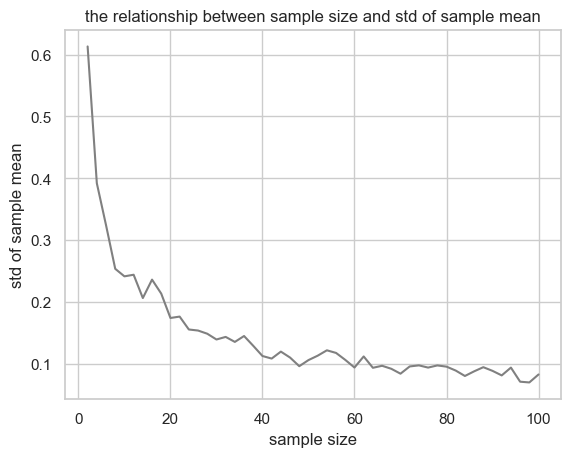

In [203]:
sample_mean_std_array=np.zeros(len(size_array))
np.random.seed(123)
for i in range(len(size_array)):
    sample_mean=calculate_sample_mean(size_array[i],100)
    sample_mean_std_array[i]=np.std(sample_mean)

plt.plot(size_array,sample_mean_std_array,color='gray')
plt.xlabel('sample size')
plt.ylabel('std of sample mean')
plt.title('the relationship between sample size and std of sample mean')


- 标准误差：样本均值的标准差，可通过公式计算：标准误差=标准差/样本容量的平方根
- 样本容量越大，标准误差越小，样本均值越集中
- 样本容量越小，标准误差越大，样本均值越分散

In [204]:
standard_error=0.8/np.sqrt(size_array)
standard_error

array([0.566, 0.4  , 0.327, 0.283, 0.253, 0.231, 0.214, 0.2  , 0.189,
       0.179, 0.171, 0.163, 0.157, 0.151, 0.146, 0.141, 0.137, 0.133,
       0.13 , 0.126, 0.123, 0.121, 0.118, 0.115, 0.113, 0.111, 0.109,
       0.107, 0.105, 0.103, 0.102, 0.1  , 0.098, 0.097, 0.096, 0.094,
       0.093, 0.092, 0.091, 0.089, 0.088, 0.087, 0.086, 0.085, 0.084,
       0.083, 0.083, 0.082, 0.081, 0.08 ])

Text(0, 0.5, 'std of sample mean')

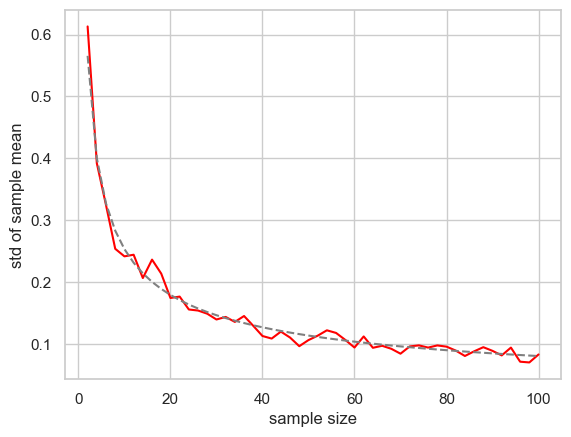

In [207]:
plt.plot(size_array,sample_mean_std_array,color='red')
plt.plot(size_array,standard_error,color='gray',linestyle='--')
plt.xlabel('sample size')
plt.ylabel('std of sample mean')


### 性质三：样本方差的均值偏离总体方差


In [216]:
# 模拟验证

sample_var_array_1=np.zeros(10000)
sample_var_array_0=np.zeros(10000)

np.random.seed(123)
for i in range(10000):
    sample_var_array_1[i]=np.var(population.rvs(size=10),ddof=1) # 样本方差
    sample_var_array_0[i]=np.var(population.rvs(size=10),ddof=0) # 样本无偏方差

np.mean(sample_var_array_1) 
np.mean(sample_var_array_0) 


(0.641, 0.573)

- 样本容量越大，样本无偏方差的均值越接近总体方差

1001

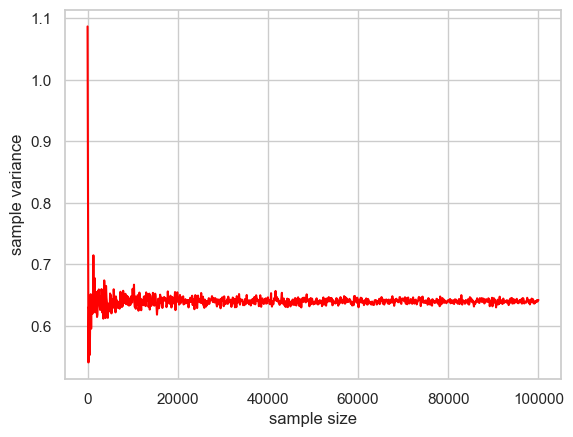

In [223]:
# 模拟验证
# 1. 生成样本容量数组
size_array=np.arange(10,100100,100)

# 2.存储样本无偏方差的空数组
sample_var_array_1=np.zeros(len(size_array))


# 3. 模拟验证
np.random.seed(123)
for i in range(len(size_array)):
    sample_var_array_1[i]=np.var(population.rvs(size=size_array[i]),ddof=1)


    
plt.plot(size_array,sample_var_array_1,color='red')
plt.xlabel('sample size')
plt.ylabel('sample variance')


df=pd.DataFrame({'sample size':size_array,'sample variance':sample_var_array_1})
df.head()
len(df)



- 中心极限定理：对于任意总体分布，样本容量越大，随机变量的和的分布越接近正态分布

C:\Users\ZYF\AppData\Local\Temp\ipykernel_42260\2448730065.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(count_coin,color='red')


(5000.011, 50.152)

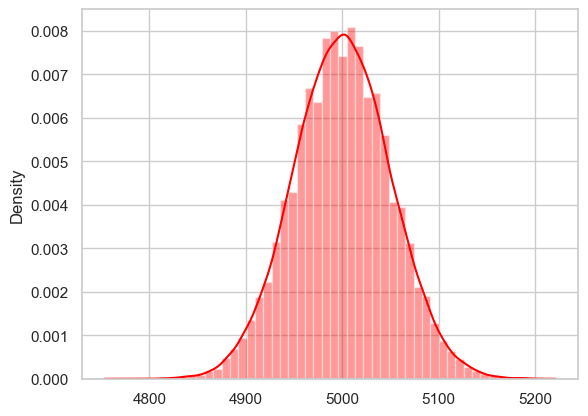

In [228]:
# 模拟验证
# 设置样本量和实验次数
n_size=10000
n_trial=50000
# 二项分布的总体coin
coin=np.array([0,1])
# 出现正面的次数-->随便变量的和
count_coin=np.zeros(n_trial)

np.random.seed(123)
for i in range(n_trial):
    count_coin[i]=np.sum(np.random.choice(coin,size=n_size,replace=True))
    
# 随机变量的和count_coin的分布近似正态分布
sns.distplot(count_coin,color='red')
np.mean(count_coin),np.std(count_coin)

# 6.正态分布及其应用

- 正态分布密度函数：$f(x)=\frac{1}{\sqrt{2\pi}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}$

In [235]:
x=3
mu=4
sigma=0.8
1/(np.sqrt(2*np.pi)*sigma)*np.exp(-((x-mu)**2)/(2*sigma**2))

0.228

In [236]:
# stats.norm.pdf()函数可以直接计算正态分布的密度函数
stats.norm.pdf(loc=4,scale=0.8,x=3)


0.228

In [238]:
# 也可以先实例化一个正态分布对象，然后直接调用pdf()方法
norm_dist=stats.norm(loc=4,scale=0.8)
norm_dist.pdf(x=3)


0.228

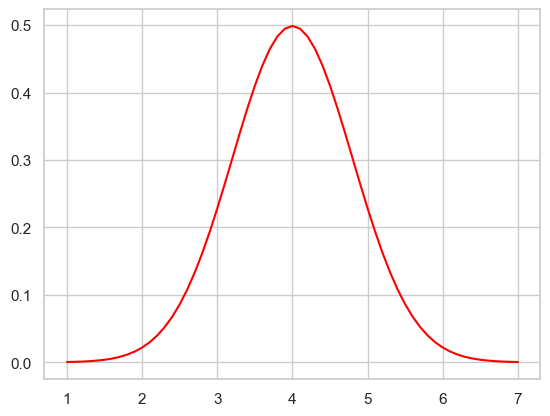

In [240]:
# 绘制密度函数图像
x_plot=np.arange(1,7.1,0.1)
plt.plot(x_plot,norm_dist.pdf(x_plot),color='red')

In [244]:
np.random.seed(1)
stimulate_sample=stats.norm.rvs(4,0.8,100000)
stimulate_sample
np.sum(stimulate_sample<=3)
np.sum(stimulate_sample<=3)/len(stimulate_sample)


0.104

- 实现累积分布函数

In [247]:
# stats.norm.cdf()函数可以直接计算正态分布的累积分布函数
stats.norm.cdf(loc=4,scale=0.8,x=3)
stats.norm.cdf(loc=4,scale=0.8,x=4)
stats.norm.cdf(loc=4,scale=0.8,x=4+0.8*3)-stats.norm.cdf(loc=4,scale=0.8,x=4-0.8*3) # 3sigma原则




0.997

- 用ppf()方法求分位数

In [249]:
# stats.norm.ppf()函数可以直接计算正态分布的分位数
stats.norm.ppf(q=0.9,loc=4,scale=0.8) # q为左侧概率


5.025

- t值的样本分布

C:\Users\ZYF\AppData\Local\Temp\ipykernel_42260\4126144428.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t_value_array,color='red')


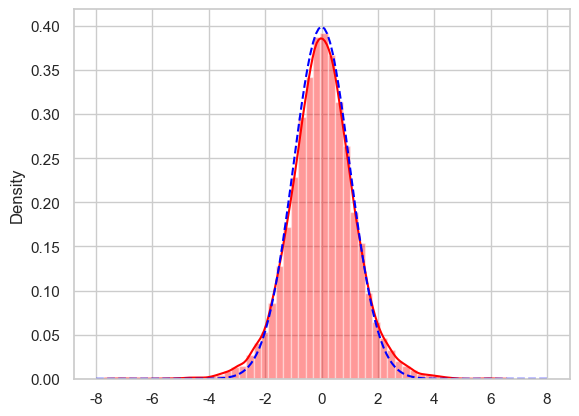

In [250]:
# 设置随机数种子
np.random.seed(1)
# 存储t值
t_value_array=np.zeros(10000)
# 实例化正态分布
norm_dist=stats.norm(4,0.8)
# 生成样本
for i in range(10000):
    sample=norm_dist.rvs(10)
    sample_mean=np.mean(sample)
    sample_std=np.std(sample,ddof=1)
    sample_se=sample_std/np.sqrt(len(sample))
    t_value_array[i]=(sample_mean-4)/sample_se

sns.distplot(t_value_array,color='red')
x=np.arange(-8,8.1,0.1)
plt.plot(x,stats.norm.pdf(x),color='blue',linestyle='--') 
# 与正态分布并不完全重合，宽度更宽，因为有标准误差，来自实际样本，因此方差大于1


t分布的方差为：（N为样本容量，则N-1为自由度）
$$\frac{n}{n-2}
，其中n为样本容量





C:\Users\ZYF\AppData\Local\Temp\ipykernel_42260\2654957085.py:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t_value_array,color='red')


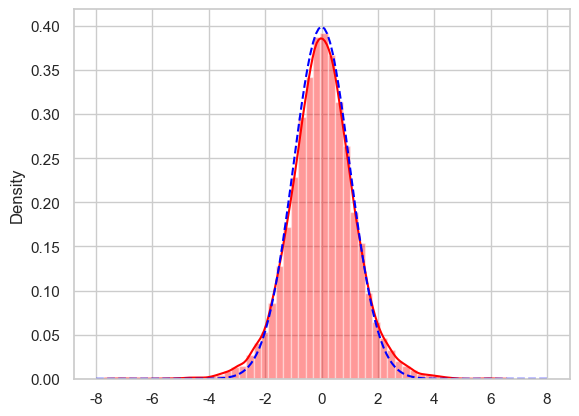

In [259]:
# 设置随机数种子
np.random.seed(1)
# 存储t值
t_value_array=np.zeros(10000)
# 实例化正态分布
norm_dist=stats.norm(4,0.8)
# 设计不同样本容量
size_array=np.array(range(2,21,2))
# 生成样本
for i in range(10000):
    sample=norm_dist.rvs(10)
    sample_mean=np.mean(sample)
    sample_std=np.std(sample,ddof=1)
    sample_se=sample_std/np.sqrt(len(sample))
    t_value_array[i]=(sample_mean-4)/sample_se

sns.distplot(t_value_array,color='red')
x=np.arange(-8,8.1,0.1)
plt.plot(x,stats.norm.pdf(x),color='blue',linestyle='--') 

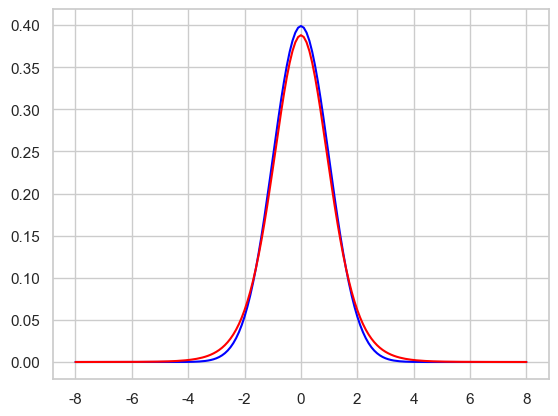

In [256]:
plt.plot(x,stats.norm.pdf(x),color='blue')#  正态分布
plt.plot(x,stats.t.pdf(x,df=9),color='red')# 自由度为9的t分布

C:\Users\ZYF\AppData\Local\Temp\ipykernel_42260\4215369953.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(t_value_array,color='black',norm_hist=True)


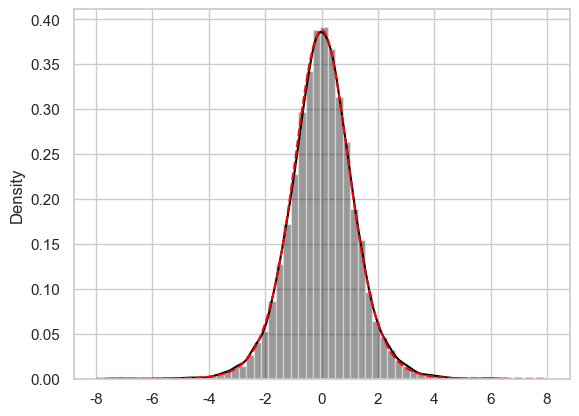

In [260]:
# 但是与实验结果对比，基本一致
sns.distplot(t_value_array,color='black',norm_hist=True)
plt.plot(x,stats.t.pdf(x,df=9),color='red',linestyle='--')

# 7.参数估计

In [261]:
fish=pd.read_csv('../pystat-code-2021-01-25/3-7-1-fish_length.csv')['length']
fish


0    4.352982
1    3.735304
2    5.944617
3    3.798326
4    4.087688
5    5.265985
6    3.272614
7    3.526691
8    4.150083
9    3.736104
Name: length, dtype: float64

- 点估计

In [263]:
mu=np.mean(fish)
mu

4.187

In [265]:
var=np.var(fish,ddof=1)
var

0.680

- 区间估计

In [282]:
# 实现区间估计 ：自由度、样本均值、标准误差
df=len(fish)-1
sigma=np.std(fish,ddof=1)
se=sigma/np.sqrt(len(fish))
se
# 把数据带入interval()函数求的置信区间
inteval=stats.t.interval(0.95,df=df,loc=mu,scale=se) # alpha是置信水平，df是自由度，loc是均值，scale是标准误差
inteval


(3.597, 4.777)

 一种求置信区间的方法
$$
P\left(-t_{0.975} \leqslant \frac{\hat{\mu} - \mu}{\hat{s}_e} \leqslant t_{0.975}\right) = 95\%
$$



In [277]:
# 验证
t_975=stats.t.ppf(0.975,df=df)
t_975
mu-se*t_975,mu+se*t_975

(3.597, 4.777)

置信区间决定因素：
1. 样本方差，样本方差越大，置信区间越宽
2. 样本容量，样本容量越大，置信区间越窄
3. 置信水平，置信水平越大，置信区间越宽

理解置信水平：置信水平是指在给定的样本容量下，置信区间的包含真实参数值的概率。

In [286]:
# 模拟验证
# 准备一个布尔值数组
be_included_array=np.zeros(20000,dtype='bool')
be_included_array

# 设置随机数种子
np.random.seed(123)
# 实例化正态分布对象
normal_dist=stats.norm(4,0.8)
# 生成置信区间样本
for i in range(20000):
    sample=normal_dist.rvs(10)
    mu=np.mean(sample)
    std=np.std(sample,ddof=1)
    se=std/np.sqrt(len(sample))
    inteval=stats.t.interval(0.95,df=len(sample)-1,loc=mu,scale=se)
    if (inteval[0]<=4 and inteval[1]>=4):
        be_included_array[i]=True

sum(be_included_array)/len(be_included_array)

0.954

# 8.假设检验

通过样本对总体进行统计学上的判断叫作假设检验

- 单样本t检验

研究对象：均值

研究目标：均值是否与某个值存在差异

- 显著性差异的三个条件，三个条件组合起来其实就是计算t统计量
1. 进行了大量调查，样本容量大 -->样本容量N
2. 数据偏差小-->样本均值与实际值的差值
3. 距离均值很远，均值差异大-->标准误差

- t检验的实现：双侧检验

In [288]:
# 读取数据
food=pd.read_csv('../pystat-code-2021-01-25/3-8-1-junk-food-weight.csv')['weight']
food.head()

0    58.529820
1    52.353039
2    74.446169
3    52.983263
4    55.876879
Name: weight, dtype: float64

零假设：薯片的均重是50g

备择假设：薯片的均重不是50g

显著性水平为p值，如果p值小于0.05，拒绝零假设，认为薯片均重与50g有显著差异

In [294]:
mu=np.mean(food)
df=len(food)-1
sigma=np.std(food,ddof=1)
se=sigma/np.sqrt(len(food))
t=(mu-50)/se
t
alpha=stats.t.cdf(t,df)
p=(1-alpha)*2
p # p值小于0.05，拒绝零假设，认为薯片均重与50g有显著差异

0.013

In [296]:
# 使用stats.ttest_1samp 函数可方便的进行单样本t检验
stats.ttest_1samp(food,50) # 第一个参数是样本，第二个参数是假设的均值  
# 返回值是t统计量和p值


TtestResult(statistic=np.float64(2.7503396831713434), pvalue=np.float64(0.012725590012524155), df=np.int64(19))

In [298]:
# 模拟实验计算p值
# 重复5万次，计算t值

# 样本大小
size=len(food)
sigma=np.std(food,ddof=1)

# 实例化正态分布
norm_dist=stats.norm(50,sigma)

# 存储t值
t_value_array=np.zeros(50000)

# 设置随机数种子
np.random.seed(123)


for i in range(50000):
    sample=norm_dist.rvs(size)
    mu=np.mean(sample)
    std=np.std(sample,ddof=1)
    se=std/np.sqrt(len(sample))
    t_value_array[i]=(mu-50)/se

(sum(t_value_array>t)/50000)*2

0.013

# 9.均值差的检验


双样本t检验

配对样本t检验 ：求两个样本均值的差值后，转化为这个差值与0的差异，就是单样本t检验的问题

In [300]:
paired_data=pd.read_csv('../pystat-code-2021-01-25/3-9-1-paired-t-test.csv')
paired_data


,person,medicine,body_temperature
0,A,before,36.2
1,B,before,36.2
2,C,before,35.3
3,D,before,36.1
4,E,before,36.1
5,A,after,36.8
6,B,after,36.1
7,C,after,36.8
8,D,after,37.1
9,E,after,36.9


In [309]:
before=paired_data.query('medicine=="before"')['body_temperature']
after=paired_data.query('medicine=="after"')['body_temperature']
before=np.array(before)
after=np.array(after)
diff=after-before
diff
stats.ttest_1samp(diff,0)


TtestResult(statistic=np.float64(2.901693483620596), pvalue=np.float64(0.044043109730074276), df=np.int64(4))

- 独立样本t检验

区别于配对样本t检验，独立样本t检验是用于比较两个独立样本的均值是否相等的检验方法，而配对样本t检验是用于比较两个相关样本的差值是否为0的检验方法。

$$
t=\frac{\hat{\mu}_{x}-\hat{\mu}_{y}}{\sqrt{\frac{{\hat{\sigma}_{x}}^{2}}{m}+\frac{{\hat{\sigma}_{y}}^{2}}{n}}}
$$

- 实现独立样本t检验

In [312]:
mean_bef=np.mean(before)
mean_aft=np.mean(after)
sigma_bef=np.std(before,ddof=1)
sigma_aft=np.std(after,ddof=1)
m=len(before)
n=len(after)
t=(mean_aft-mean_bef)/np.sqrt((sigma_bef**2/m)+(sigma_aft**2/n))
t



3.156

In [314]:
# 利用stats.ttest_ind函数实现独立样本t检验
stats.ttest_ind(before,after,equal_var=False) # 返回t统计量和p值

TtestResult(statistic=np.float64(-3.1557282344421034), pvalue=np.float64(0.013484775682079892), df=np.float64(7.998478291882638))

- p值操纵

对于同一种数据，不同的检验方法得到的p值是不同的。

# 10.列联表检验

也叫$\chi^{2}$检验(卡方检验)


$$
\chi^{2} = \sum_{i=1}^{m}\sum_{j=1}^{n} \frac{(O_{ij} - E_{ij})^{2}}{E_{ij}}
$$
其中，$O_{ij}$是观测频数，$E_{ij}$是期望频数。

In [316]:
# 使用自由度为1的卡方分布的累积分布函数计算p值
p=1-stats.chi2.cdf(6.67,df=1)
p

0.010

In [317]:
chi_data=pd.read_csv("../pystat-code-2021-01-25/3-10-1-click_data.csv") 
chi_data


,color,click,freq
0,blue,click,20
1,blue,not,230
2,red,click,10
3,red,not,40


In [319]:
# 使用pivot_table()函数创建列联表
chi_table=pd.pivot_table(
    data=chi_data,
    values='freq',
    index='color',
    columns='click',
    aggfunc='sum')
chi_table   

click,click,not
color,,
blue,20,230
red,10,40


$$


In [322]:
# stats.chi2_contingency 函数进行卡方检验
chi2,p,df,expected=stats.chi2_contingency(chi_table,correction=False)
chi2,p,df,expected


(6.667,
 0.010,
 1,
 array([[ 25., 225.],
        [  5.,  45.]]))